In [1]:
from rbfPUCurlNoise.triang_mesh          import TriMesh, refine_mesh_1to4
from rbfPUCurlNoise.patches       import PatchCoverage
from rbfPUCurlNoise.rbf           import RBF
from rbfPUCurlNoise.interpolator  import PUMInterpolator
from rbfPUCurlNoise.potential import NoisePotential2D
from rbfPUCurlNoise.utils import plot_noise_mesh, plot_mesh, plot_layers_mesh, refine_around_brder
from rbfPUCurlNoise.visualization import plot_patches, plot_patches_v2, plot_combined_field
import matplotlib.pyplot as plt
import numpy as np
from perlin_noise import PerlinNoise
import triangle
from matplotlib.ticker import ScalarFormatter
from collections import defaultdict
from matplotlib.path import Path
import meshio

In [2]:
def save_mesh_paraview(mesh_to_save, nx, ny, vels=None, phi=None, psi=None,  sdf=None, out_name="lic.vtu", save_norm=False):
    x = mesh_to_save[:,0]
    y = mesh_to_save[:,1]
    points = np.column_stack([x, y, np.zeros_like(x)])

    quads = []

    for i in range(nx - 1):
        for j in range(ny - 1):

            v0 = i * ny + j
            v1 = (i + 1) * ny + j
            v2 = (i + 1) * ny + (j + 1)
            v3 = i * ny + (j + 1)

            quads.append([v0, v1, v2, v3])

    quads = np.array(quads)

    # Disctionary to save the data
    point_data = {}

    if vels is not None:
        assert vels.shape[0] == mesh_to_save.shape[0]
        # velocity per vertex
        u = vels[:,0]
        v = vels[:,1]
        velocity = np.column_stack([u, v, np.zeros_like(u)])
        point_data["velocity"] = velocity

    if phi is not None:
        point_data["phi"] = phi
    
    if psi is not None:
        point_data["psi"] = psi

    if sdf is not None:
        point_data["sdf"] = sdf
    
    if save_norm:
        M = np.max(np.abs(phi))
        if M == 0:
            M = 1.0
        original_norm = phi / M
        masked_norm = psi / M

        point_data["phi_norm"] = original_norm
        point_data["psi_norm"] = masked_norm

        print("Normalization factor:", M)

        print("Original normalized range:")
        print(original_norm.min(), original_norm.max())

        print("Masked normalized range:")
        print(masked_norm.min(), masked_norm.max())


    out_mesh = meshio.Mesh(points=points,
                           cells=[("quad", quads)],
                            point_data=point_data)

    meshio.write(out_name, out_mesh)

def compute_finite_diff(arr, axis, dx=1.0):
    diff = np.zeros_like(arr)
    rolled_plus = np.roll(arr, -1, axis=axis)
    rolled_minus = np.roll(arr, 1, axis=axis)
    diff = (rolled_plus - rolled_minus) / (2.0 * dx)
    return diff

def divergence(u, v, dx=1.0):
    dudx = (np.roll(u, -1, axis=0) - np.roll(u, 1, axis=0)) / (2*dx)
    dvdy = (np.roll(v, -1, axis=1) - np.roll(v, 1, axis=1)) / (2*dx)

    return dudx + dvdy

def compute_curl_2D(arr):
    dx = compute_finite_diff(arr, 0)
    dy = compute_finite_diff(arr, 1)
    return np.array([dy, -dx])

def generate_perlin_noise_scalar_field_2d(noise, shape, freq=1.0):
    noise_grid = np.zeros(shape)

    for i in range(shape[0]):
        ind_i = i/shape[0]
        for j in range(shape[1]):
            ind_j = j/shape[1]
            noise_grid[i][j] = noise([freq * ind_i, freq* ind_j])
    return noise_grid

def generate_perlin_noise_grid_2d(noise, X, Y, freq=1.0):
    noise_grid = np.zeros_like(X)

    nx, ny = X.shape

    for i in range(nx):
        for j in range(ny):
            noise_grid[i, j] = noise([
                freq * X[i, j],
                freq * Y[i, j]
            ])

    return noise_grid

def distance_point_to_segment(p, a, b):
    ap = p - a # vector from a to point (a is the end of the segment line)
    ab = b - a # vector from a to b (vector in the segment line)
    # projection of ap into ab, dot product divided by the norm
    t = np.dot(ap, ab) / np.dot(ab, ab)
    t = np.clip(t, 0.0, 1.0)
    # locating the closest point in the segment (parametric equation of the segment)
    closest = a + t * ab
    # return the Euclidean distance
    return np.linalg.norm(p - closest), closest

def sdf_distance_to_segments_min(vertices_grid, vertices_mesh, bdry_edges, interior_nodes, exterior_nodes):
    nverts = vertices_grid.shape[0]
    segments = bdry_edges

    sdf = np.full(nverts, np.inf)
    closest_pts = np.zeros((nverts, 2))

    for vertex in interior_nodes:
        #print(vertex)
        p = vertices_grid[vertex]
        for a, b in segments:
            a_p = vertices_mesh[a]
            b_p = vertices_mesh[b]
            d, closest = distance_point_to_segment(p, a_p, b_p)
            # This is the point where the hard min distance is computed
            # following Bridson's approach
            if d < sdf[vertex]:
                sdf[vertex] = d
                closest_pts[vertex] = closest

    #self.sdf[np.isinf(self.sdf)] = 0
    for vertex in exterior_nodes:
        sdf[vertex] = 0.0
        closest_pts[vertex] = vertices_grid[vertex]
    
    return sdf

def smoothstep(x):
        return x*x*(3 - 2*x)

def ramp_box_boundary(phi, d0):
    A = np.zeros_like(phi)

    band = (phi > 0) & (phi < d0)
    #A[band] = phi[band] / d0
    r = phi[band] / d0
    A[band] = smoothstep(r)

    A[phi >= d0] = 1.0

    return A

def noise_potential_ramp_mult_sdf(phi, sdf, d0=1.0):
    # phi is the potential noise field

    psi = np.zeros(phi.shape)

    #self.mesh.sdf_distance_to_segments()
    #phi = self.mesh.get_sdf_field()
    ramp_field = ramp_box_boundary(sdf, d0)

    print(ramp_field.shape)

    for ind, f_value in enumerate(phi):
        #print(ind, vertex)
        #print(nbrs_dict[ind]
        psi[ind]= f_value * ramp_field[ind]
        
    return psi

In [3]:
noise_seed = 7
freq = 1

noise = PerlinNoise(octaves=3, seed=noise_seed)

dx:  0.031746031746031744
4096


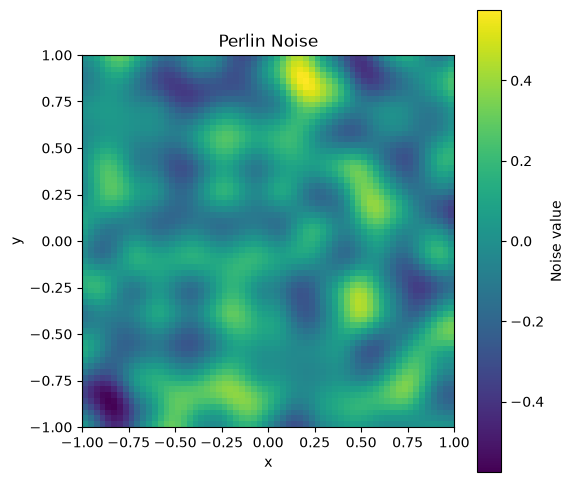

In [4]:
nx, ny = 64, 64
x_min, x_max = -1, 1
y_min, y_max = -1, 1

dx = (x_max-x_min)/(nx-1)

print("dx: ", dx)

x = np.linspace(x_min, x_max, nx)
y = np.linspace(y_min, y_max, ny)

X, Y = np.meshgrid(x, y, indexing="ij")

grid_points = np.column_stack((X.ravel(), Y.ravel()))

print(grid_points.shape[0])

# assigning noise values for each grid cell
noise_grid = generate_perlin_noise_grid_2d(noise, X, Y, freq)

plt.figure(figsize=(6,6))

plt.imshow(
    noise_grid.T,
    origin="lower",
    extent=[x_min, x_max, y_min, y_max],
    cmap="viridis"
)

plt.colorbar(label="Noise value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Perlin Noise")

plt.show()


Num vertices: 853
-83.5 111.0
-0.9 0.9


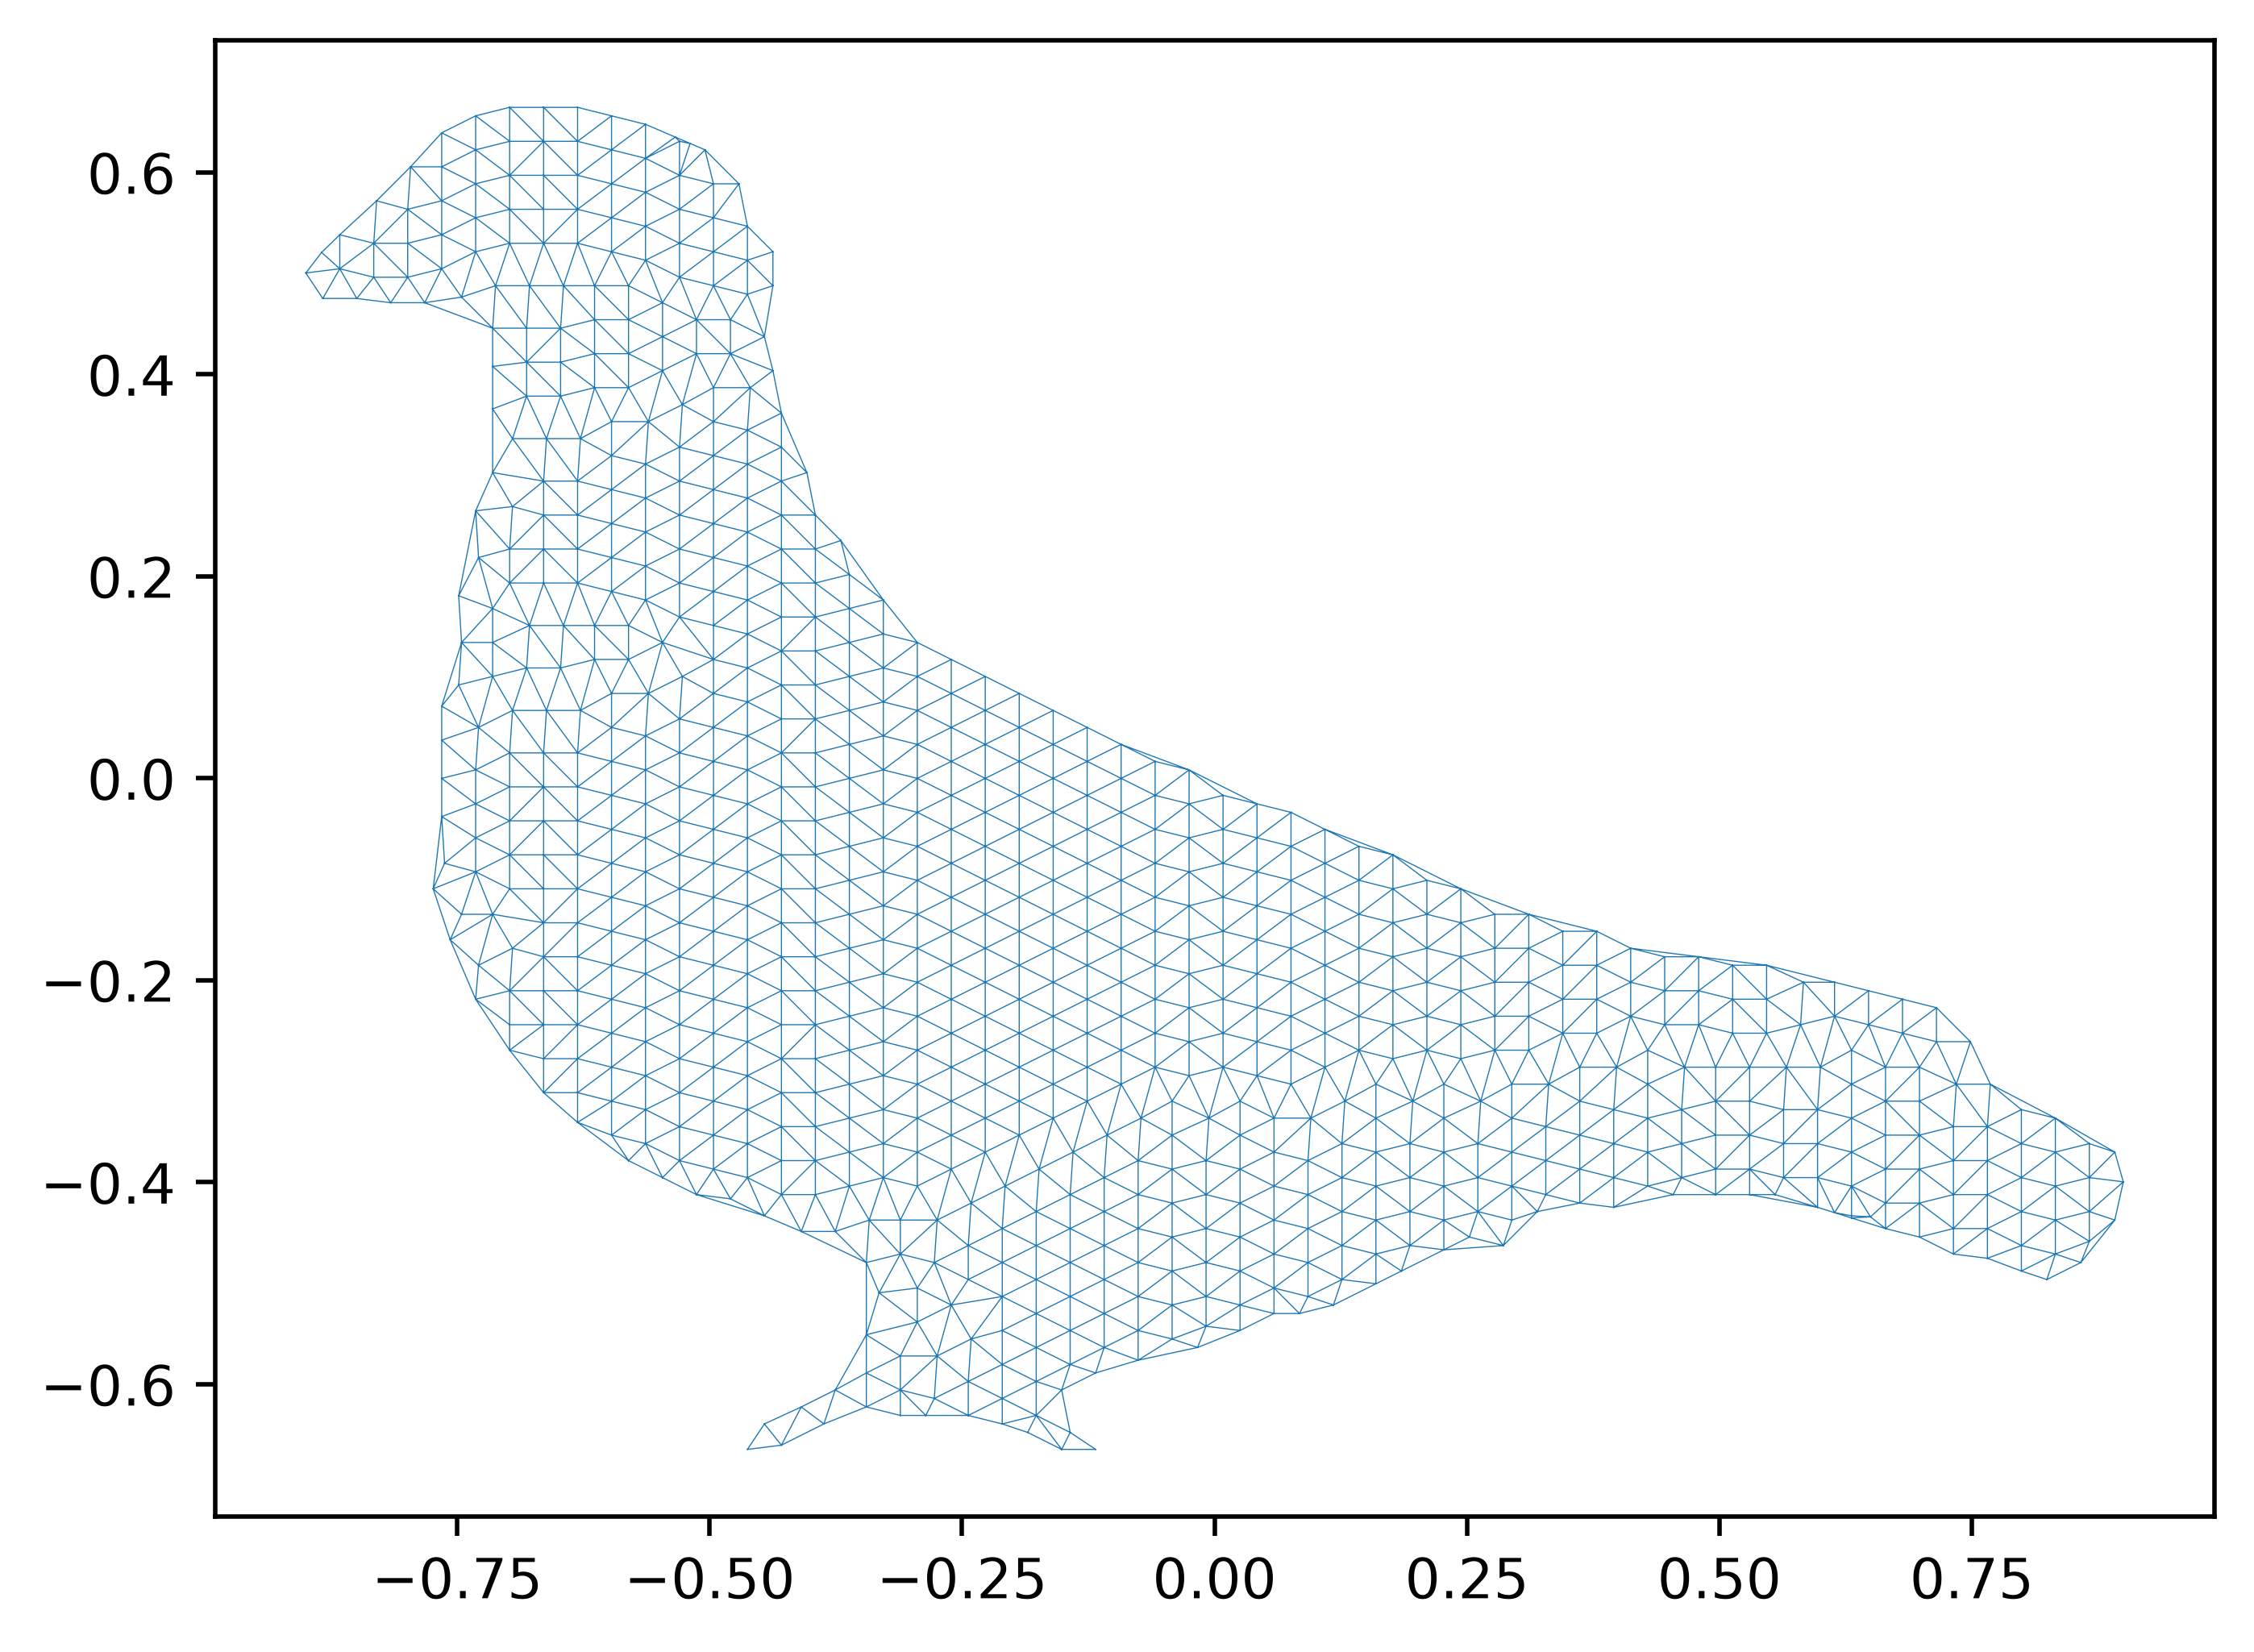

In [5]:
dovedp = triangle.load("..\\meshes\\triangle_files", "dovedp")
dovedp_mesh = triangle.triangulate(dovedp, "pq5a150")

print("Num vertices:", dovedp_mesh["vertices"].shape[0])

print(dovedp_mesh["vertices"].min(), dovedp_mesh["vertices"].max())
mins = dovedp_mesh["vertices"].min(axis=0)
maxs = dovedp_mesh["vertices"].max(axis=0)
# Center of the bounding box
center = 0.5 * (mins + maxs)

# Largest dimension of the bounding box
max_extent = np.max(maxs - mins)

# Normalizing mesh vertices range
dovedp_mesh["vertices"] = 1.8 * (dovedp_mesh["vertices"] - center) / max_extent
print(dovedp_mesh["vertices"].min(), dovedp_mesh["vertices"].max())

dovedp_mesh_obj = TriMesh(dovedp_mesh)
plot_mesh(dovedp_mesh)

In [6]:
bdry_edges = dovedp_mesh_obj.get_boundary_edges()
print(bdry_edges)

adj = defaultdict(list)

for a, b in bdry_edges:
    adj[a].append(b)
    adj[b].append(a)

start = bdry_edges[0][0]
ordered = [start]

previous = None
current = start

while True:
    neighbors = adj[current]
    if previous is None:
        nxt = neighbors[0]
    else:
        nxt = neighbors[0] if neighbors[0] != previous else neighbors[1]
    if nxt == start:
        break
    ordered.append(nxt)
    previous = current
    current = nxt

print(ordered)

bdry_coords = []
print(dovedp_mesh["vertices"])

for vertex in ordered:
    bdry_coords.append(dovedp_mesh["vertices"][vertex])

print(bdry_coords)

polygon = np.array(bdry_coords)

path = Path(polygon)

inside = path.contains_points(grid_points)

print(inside)

inside_points = grid_points[inside]
outside_points = grid_points[~inside]

inside_indices = np.nonzero(inside)[0]
outside_indices = np.nonzero(~inside)[0]


[(np.int32(100), np.int32(129)), (np.int32(72), np.int32(100)), (np.int32(129), np.int32(167)), (np.int32(167), np.int32(197)), (np.int32(44), np.int32(72)), (np.int32(30), np.int32(44)), (np.int32(197), np.int32(227)), (np.int32(227), np.int32(290)), (np.int32(24), np.int32(30)), (np.int32(22), np.int32(24)), (np.int32(21), np.int32(22)), (np.int32(20), np.int32(21)), (np.int32(291), np.int32(321)), (np.int32(288), np.int32(319)), (np.int32(288), np.int32(291)), (np.int32(319), np.int32(346)), (np.int32(290), np.int32(320)), (np.int32(346), np.int32(371)), (np.int32(320), np.int32(368)), (np.int32(345), np.int32(369)), (np.int32(321), np.int32(345)), (np.int32(394), np.int32(418)), (np.int32(368), np.int32(369)), (np.int32(371), np.int32(394)), (np.int32(418), np.int32(441)), (np.int32(19), np.int32(20)), (np.int32(19), np.int32(27)), (np.int32(26), np.int32(27)), (np.int32(36), np.int32(49)), (np.int32(26), np.int32(36)), (np.int32(47), np.int32(48)), (np.int32(46), np.int32(47)), (n

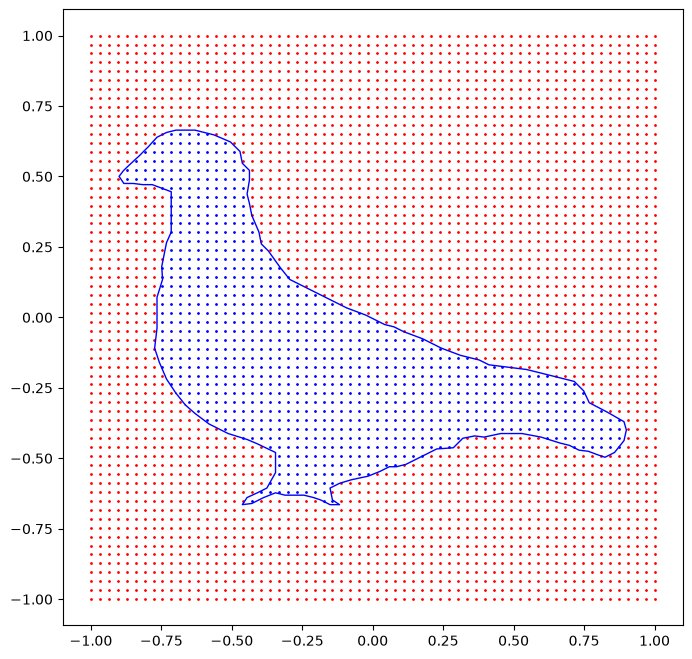

In [7]:
plt.figure(figsize=(8,8))

plt.plot(
    polygon[:,0],
    polygon[:,1],
    "-b",
    lw=1
)

# close the polygon
plt.plot(
    [polygon[-1,0], polygon[0,0]],
    [polygon[-1,1], polygon[0,1]],
    "-b",
    lw=1
)

#plt.scatter(polygon[:,0], polygon[:,1], c="k", s=20)

plt.scatter(
    inside_points[:,0],
    inside_points[:,1],
    s=1,
    c="blue"
)

plt.scatter(
    outside_points[:,0],
    outside_points[:,1],
    s=1,
    c="red"
)

plt.axis("equal")
plt.savefig("grid_representation.png",bbox_inches="tight",dpi=300, pad_inches=0)

[[-0.9         0.50046729]
 [-0.88317757  0.47523364]
 [-0.86635514  0.53831776]
 ...
 [ 0.64963493 -0.43422897]
 [ 0.61401869 -0.43002336]
 [-0.51939252  0.62873832]]
Noise grid shape: (4096,)
(4096,)


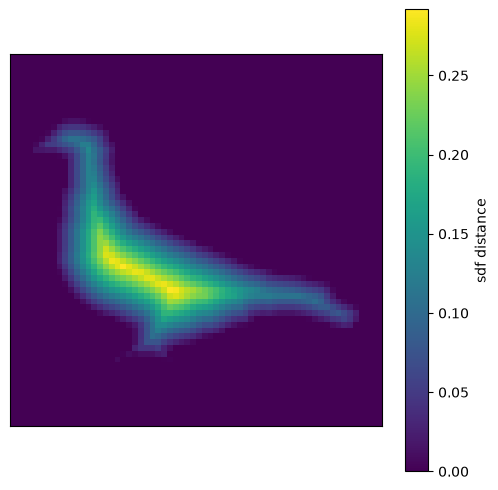

In [8]:
print(dovedp_mesh["vertices"])
sdf = sdf_distance_to_segments_min(grid_points, dovedp_mesh["vertices"], bdry_edges,
                                    inside_indices, outside_indices)

print("Noise grid shape:", noise_grid.ravel().shape)

psi = noise_potential_ramp_mult_sdf(noise_grid.ravel(), sdf, d0=0.2)

plt.figure(figsize=(6,6))

plt.imshow(
    sdf.reshape((nx,ny)).T,
    origin="lower",
    extent=[x_min, x_max, y_min, y_max],
    cmap="viridis"
)

plt.colorbar(label="sdf distance")
plt.xticks([])
plt.yticks([])

plt.savefig("sdf_grid.png",bbox_inches="tight",dpi=300, pad_inches=0)

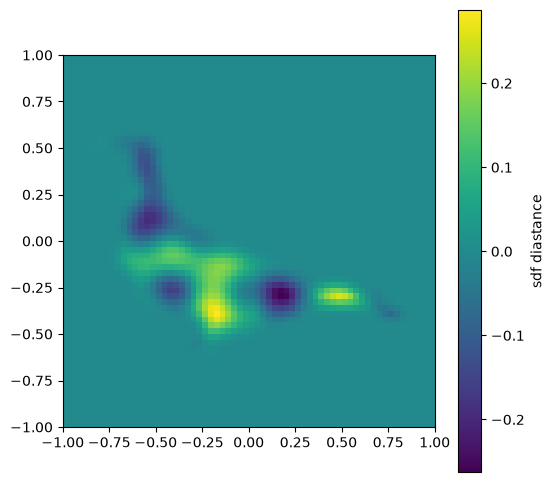

In [9]:
plt.figure(figsize=(6,6))

plt.imshow(
    psi.reshape((nx,ny)).T,
    origin="lower",
    extent=[x_min, x_max, y_min, y_max],
    cmap="viridis"
)

plt.colorbar(label="sdf diastance")

plt.show()

In [10]:
print(psi.shape)
psi_reshaped = psi.reshape((nx,ny))
vels = compute_curl_2D(psi_reshaped)
print(vels.shape)
vels = np.column_stack((
    vels[0].ravel(),
    vels[1].ravel()
))
print(grid_points.shape)

phi = noise_grid.ravel()
save_mesh_paraview(grid_points, nx, ny, vels=vels, phi=phi, psi=psi,  sdf=sdf, out_name="lic_grid.vtu", save_norm=True)

(4096,)
(2, 64, 64)
(4096, 2)
Normalization factor: 0.5756661808876796
Original normalized range:
-1.0 0.9999999999999994
Masked normalized range:
-0.45597198056132865 0.49868818835046874


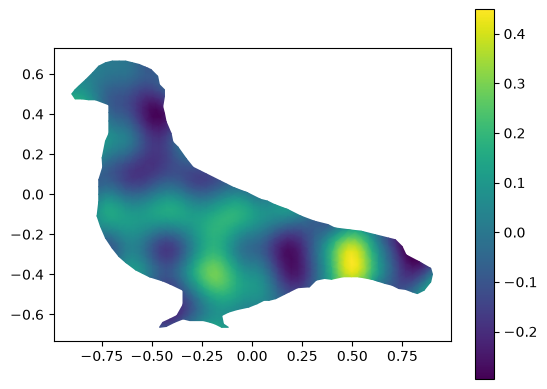

354
248
99
292
266
154

Coverage Summary:
  n_patches           : 6
  H                   : 0.5
  delta               : 0.2
  min_nodes           : 99
  max_nodes           : 392
  mean_nodes          : 246.16666666666666
  min_coverage        : 1
  max_coverage        : 3
  mean_coverage       : 1.731535756154748
  full_coverage       : True
[np.float64(0.4242640687119285), np.float64(0.4242640687119285), np.float64(0.4242640687119285), np.float64(0.4242640687119285), np.float64(0.4242640687119285), np.float64(0.4242640687119285)]
(853,)
(853,)
(853, 2)
Normalization factor: 0.4490328981090537
Original normalized range:
-0.6584349172844052 1.0
Masked normalized range:
-0.5896752559827647 0.6375239882079392


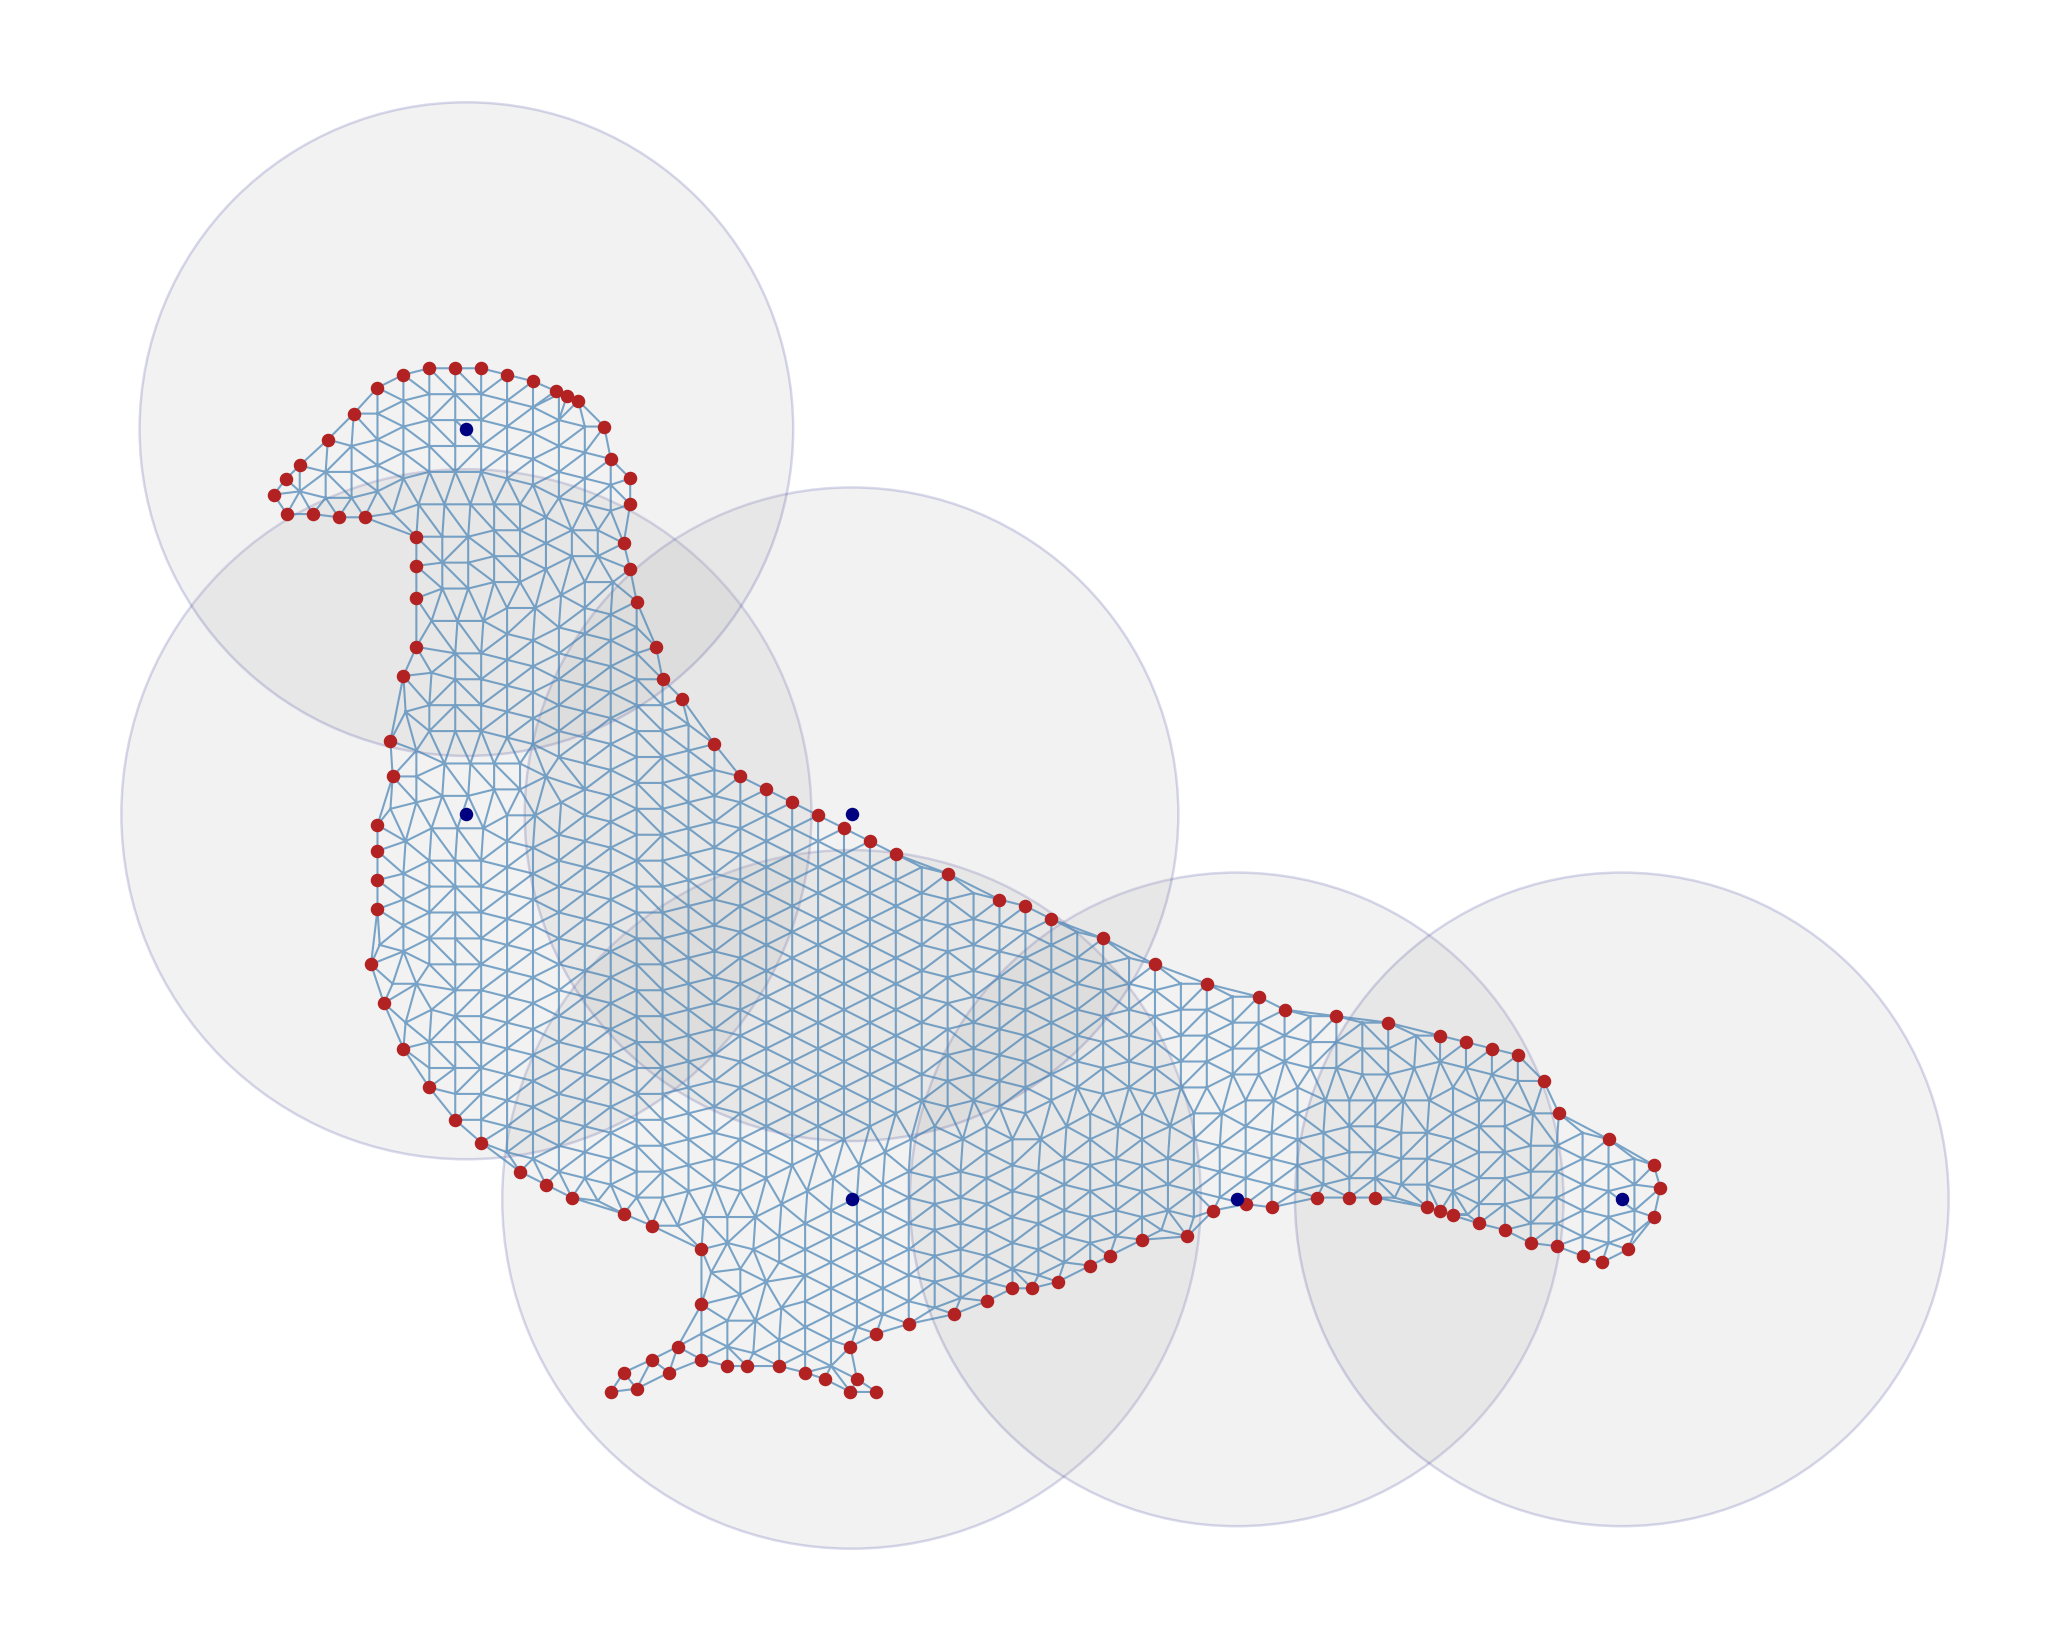

In [11]:

mesh_noise = dovedp_mesh_obj.generate_mesh_noise_scalar_field(noise, freq)
plot_noise_mesh(dovedp_mesh, mesh_noise)

dovedp_mesh_obj.sdf_distance_to_segments_min()
sdf = dovedp_mesh_obj.get_sdf_field()

coverage = PatchCoverage(dovedp_mesh_obj, H=0.5, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura

print(coverage.radius_list)
epsilon = 1.0

potential_sdf = NoisePotential2D(dovedp_mesh_obj, coverage, RBF(epsilon=epsilon))

psi = potential_sdf.noise_potential_ramp_mult_sdf(mesh_noise, sdf, d0=0.2)
#plot_noise_mesh(dog_mesh, psi)

#plot_patches(dog_mesh_obj, coverage, ax=None, title=f"Coverage: {len(coverage)} patches)")

ax = plot_patches_v2(dovedp_mesh_obj, coverage, alpha=0.15)
plt.savefig("patches_dovedp_0.5.pdf",bbox_inches="tight", pad_inches=0)
plt.savefig("patches_dovedp_0.5.png",bbox_inches="tight", pad_inches=0)

# With boundary treatment
potential_sdf.fit(psi)

grad_x, grad_y = potential_sdf.gradient(dovedp_mesh["vertices"])

print(grad_x.shape)
print(grad_y.shape)

curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))

print(curl.shape)

dovedp_mesh_obj.save_mesh_paraview(dovedp_mesh, vels=curl, phi=mesh_noise, psi=psi, sdf=sdf, out_name="dovedp_05.vtu", save_norm=True)